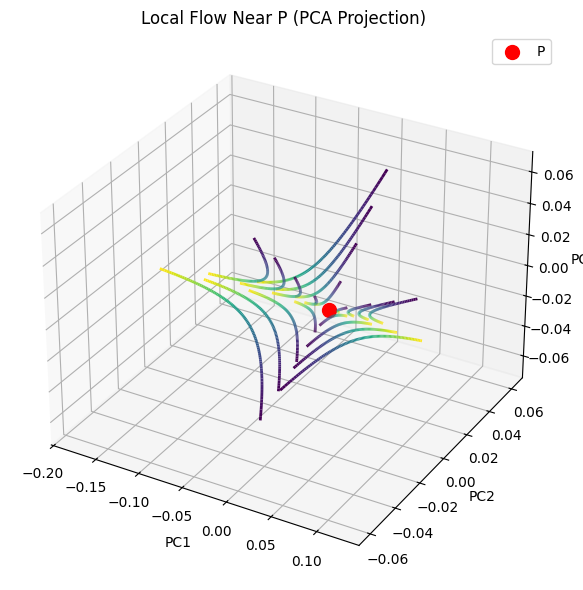

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.decomposition import PCA

def deterministic_sphere_sampling(P, n_samples, n_radial, r):
    """
    Deterministically sample points in an N-dimensional ball centered at P.

    Parameters
    ----------
    P : array_like, shape (N,)
        Center point
    n_samples : int
        Total number of sample points
    r : float
        Maximum radius

    Returns
    -------
    X0 : list of ndarray
        List of initial conditions
    """
    P = np.asarray(P)
    N = P.size

    # Number of radial shells (heuristic)
    # n_radial = int(np.sqrt(n_samples))
    # n_radial = max(1, n_radial)
    n_dirs = n_samples // n_radial

    # Deterministic directions via evenly spaced angles in index space
    dirs = []
    for i in range(n_dirs):
        v = np.array([np.cos((i+1)*(j+1)) for j in range(N)])
        v /= np.linalg.norm(v)
        dirs.append(v)

    # Deterministic radii
    radii = np.linspace(0.2*r, r, n_radial)

    X0 = []
    for rho in radii:
        for v in dirs:
            X0.append(P + rho * v)
            if len(X0) >= n_samples:
                return X0

    return X0

# -----------------------------
# Parameters
# -----------------------------
N = 10
k = 20
delta = 0.05
T = 3.0
nt = 100
P = np.zeros(N)

# -----------------------------
# Linear saddle system
# -----------------------------
eigvals = np.array([0.5] + [-1.0]*(N-1))   # 1 unstable, 9 stable
A = np.diag(eigvals)

def f(t, x):
    return A @ (x - P)

# -----------------------------
# Sample initial conditions
# -----------------------------
rng = np.random.default_rng(1)
directions = rng.normal(size=(k, N))
directions /= np.linalg.norm(directions, axis=1)[:, None]
# radii = rng.uniform(0, delta, size=k)
# X0 = P + directions * radii[:, None]

X0 = deterministic_sphere_sampling(P, 20, 4, 0.1)

# -----------------------------
# Simulate trajectories
# -----------------------------
t_eval = np.linspace(0, T, nt)
trajectories = []

for x0 in X0:
    sol = solve_ivp(f, [0, T], x0, t_eval=t_eval)
    trajectories.append(sol.y.T)

# -----------------------------
# PCA
# -----------------------------
X_all = np.vstack(trajectories)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_all)

# Split trajectories back
idx = 0
traj_pca = []
for tr in trajectories:
    traj_pca.append(X_pca[idx:idx+len(tr)])
    idx += len(tr)

P_pca = pca.transform(P.reshape(1, -1))[0]

# -----------------------------
# Plot
# -----------------------------

from mpl_toolkits.mplot3d.art3d import Line3DCollection

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
cmap = plt.cm.viridis

for tr in traj_pca:
    # Build line segments
    segments = np.stack([tr[:-1], tr[1:]], axis=1)
    tcolor = np.linspace(0, 1, len(segments))

    lc = Line3DCollection(segments, cmap=cmap)
    lc.set_array(tcolor)
    lc.set_linewidth(2.0)
    ax.add_collection3d(lc)

   
# Plot P
ax.scatter(*P_pca, color='red', s=100, label='P', zorder=10)

ax.set_title("Local Flow Near P (PCA Projection)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.tight_layout()
plt.show()